# Tutorial 9: Hybrid Series + Hanger Resonators

Tutorials 3 and 8 treat **inline chains** and **hanger / notch** resonators
separately. But they may also be combined into one chain and analyzed as a whole.

In this tutorial, we will learn how to:
1. Construct a chain of resonators with both inline and hanger distributed CPWs.
2. Assemble a lumped system by fitting each piece with its respective LOM (`fit_lom` for the series resonator, `fit_lom_hanger`
for each hanger)
3. Check the accuracy of the circuit model for the hybrid system.

For this tutorial, we will use the 3-resonator system: 

```
[P1] -- Cc -- Ctog -- CPW_Purcell -- Ctog -- Cc --||-- hang1 -- hang2 -- [P2]
      \_____________ series / inline _____________/   \___ hangers ___/
```

It is also drawn later during the tutorial in `hybrid_schematic_2port`. 


## Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf

import simpleLOMs as sl

sl.apply_style()




resonators: 1 inline Purcell (6.5 mm) + 2 open hangers [7.0, 8.0] mm


Our CPWs will all share a common `CPWParams` for the sake of this tutorial, but this can be changed in systems where the hybrid network has CPWs with different width or thickness.

In [ ]:
cpw = sl.CPWParams(ep_r=11.45)
freq = rf.Frequency(5e9, 11e9, 4001, unit="Hz")
Z0 = 50.0

The series CPW, which we'll refer to as the Purcell filter, uses the familiar inline topology.

In [ ]:

d_purcell = 6.5e-3
Ccs_p = [8e-15, 8e-15]
Ctogs_p = [1e-14, 1e-14]
seg_purcell_cpw = [{"kind": "cpw", "d": d_purcell}]

THe inline resonator is then followed by two open hangers on a through feedline.

In [ ]:

d_hangers = [7.0e-3, 8.0e-3]         
Cc_taps = [30e-15, 30e-15]
seg_hangers_cpw = [
    {"kind": "cpw", "d": d, "termination": "open"} for d in d_hangers
]

print(f"resonators: 1 inline Purcell ({d_purcell*1e3:.1f} mm)"
      f" + {len(d_hangers)} open hangers {[d*1e3 for d in d_hangers]} mm")

## 1. Build the CPW hybrid (ground truth)

Build each block with its native network builder, then cascade them into one
2-port. The inline Purcell puts a **transmission peak** near its loaded
resonance; each hanger puts a **notch** in $|S_{21}|$.


## 1a. Network objects

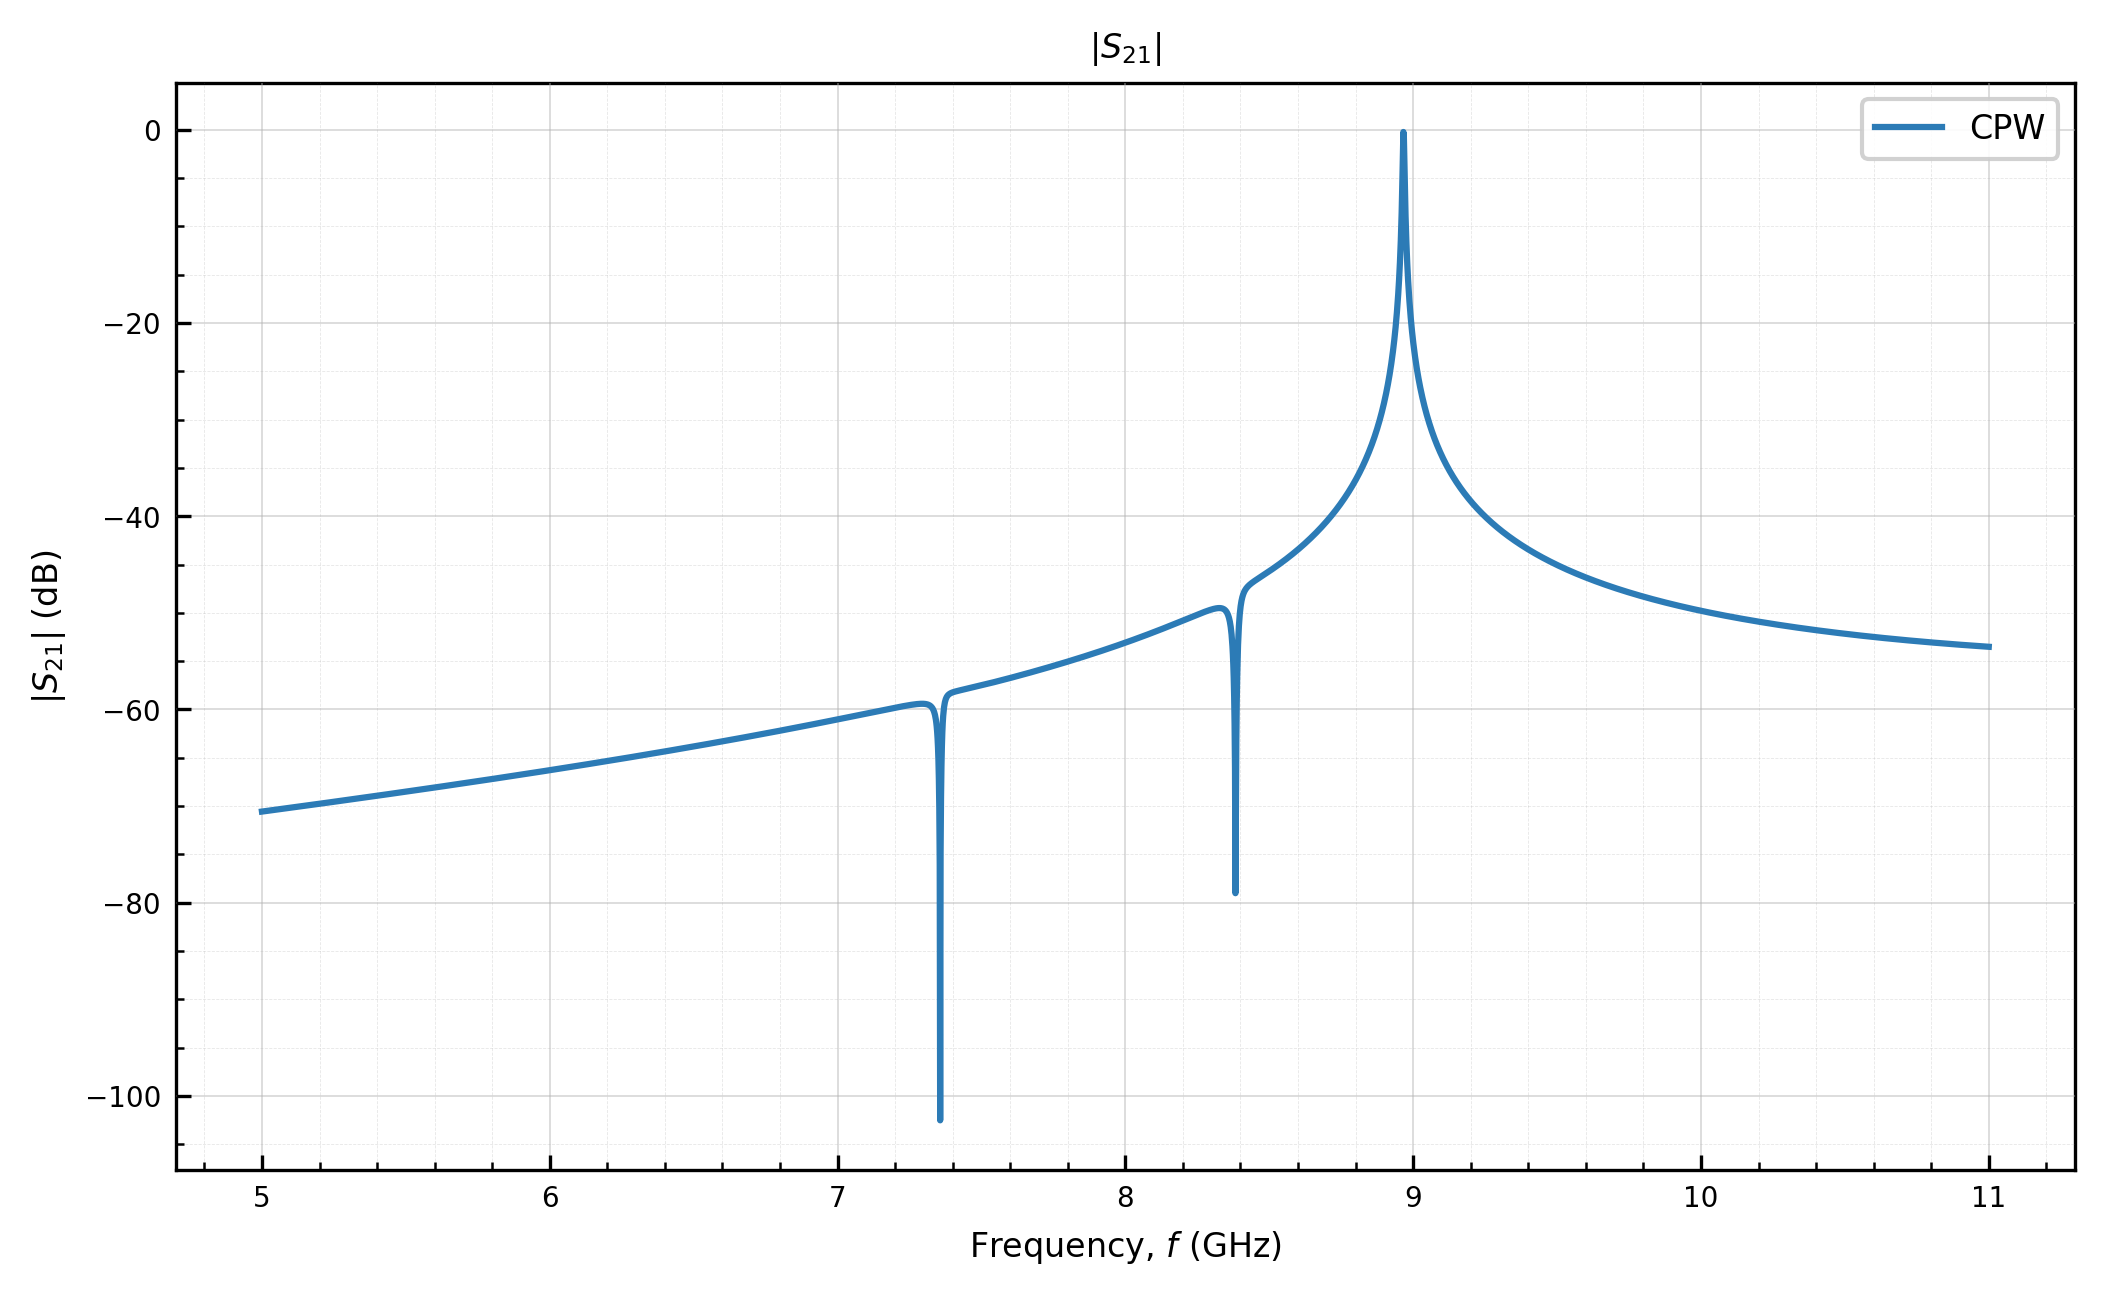

S21 peaks  (GHz): [7.2935 8.327  8.966 ]
S21 notches (GHz): [7.3565, 8.3825]


In [ ]:
purcell_cpw = sl.resonator_chain_network_2port(
    freq, seg_purcell_cpw, Ccs_p, Ctogs_p, cpw_params=cpw, Z0=Z0,
)
hangers_cpw = sl.hanger_resonator_network_2port(
    freq, seg_hangers_cpw, Cc_taps, cpw_params=cpw, Z0=Z0,
)
hybrid_cpw = purcell_cpw ** hangers_cpw


## 1b. Plot the network transmission

In [ ]:
sl.plot_transmission({"CPW hybrid": hybrid_cpw}, m=1, n=0)

peaks_cpw = np.sort(sl.resonances_from_s_max(hybrid_cpw, m=1, n=0))
notches_cpw = sl.notches_below(hybrid_cpw, thresh=0.7)
print("S21 peaks  (GHz):", np.round(peaks_cpw / 1e9, 4))
print("S21 notches (GHz):", [round(f, 4) for f in notches_cpw])

As expected there are is one major peak and two notches visible on the graph.

## 2. Draw the hybrid schematic

`hybrid_schematic_2port` puts the inline Purcell and both hangers on **one**
rail — the schematic counterpart of cascading the two networks. Same segment /
capacitor arguments as the network builders.


In [4]:
from pathlib import Path

figdir = Path("figures")
figdir.mkdir(exist_ok=True)

sch_cpw = sl.hybrid_schematic_2port(
    seg_purcell_cpw, Ccs_p, seg_hangers_cpw, Cc_taps,
    inline_Ctogs=Ctogs_p, cpw_params=cpw, freq=freq, Z0=Z0,
    annotations={"block": "hybrid CPW (Purcell + hangers)"},
)
sch_cpw.save_svg(figdir / "hybrid_cpw.svg")
sch_cpw.save_html(figdir / "hybrid_cpw.html")
print("saved figures/hybrid_cpw.svg|.html")
print("groups:", [g["label"] for g in sch_cpw.groups])
print("components:", [c.id for c in sch_cpw.components])
sch_cpw


saved figures/hybrid_cpw.svg|.html
groups: ['resonator 1', 'hanger 1', 'hanger 2']
components: ['P1', 'Cc1', 'Ctog1', 'TL1', 'Ctog2', 'Cc2', 'H1', 'H2', 'P2']


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.schematics.builders.hybrid_schematic_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'res1', 'label': 'resonator 1'}, {'id': 'hang1', 'label': 'hanger 1'}, {'id': 'hang2', 'label': 'hanger 2'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50.0}), Component(id='Cc1', type='cap', label='C_{c1}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='Ctog1', type='cap', label='C_{tog1}', value='10.00 fF', ports=['a', 'gnd'], group='res1', orient='shunt', props={'C': 1e-14}), Component(id='TL1', type='tline', label='CPW 1', value='\\ell = 6.50 mm', ports=['in', 'out'], group='res1', orient='series', props={'length': 0.0065, 'Z0': 46.426279489739365}), Component(id='Ctog2', type='cap', label='C_{tog2}', value='10.00 fF', ports=['a', 'gnd'], group='res1', orient='shunt', props={'C': 1e-14}), Component(id='Cc2', type='cap', label='C_{c2}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='H1', type='branch', label='', value='', ports=['a', 'gnd'], group='hang1', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c1}', 'value': '30.00 fF'}, {'type': 'tline', 'label': 'CPW 1', 'value': '\\ell = 7.00 mm (open)'}]}), Component(id='H2', type='branch', label='', value='', ports=['a', 'gnd'], group='hang2', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c2}', 'value': '30.00 fF'}, {'type': 'tline', 'label': 'CPW 2', 'value': '\\ell = 8.00 mm (open)'}]}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50.0})], nets=[Net(id='n1', ports=['P1.out', 'Cc1.a']), Net(id='n2', ports=['Cc1.b', 'Ctog1.a']), Net(id='n3', ports=['Ctog1.gnd', 'GND']), Net(id='n4', ports=['Cc1.b', 'TL1.in']), Net(id='n5', ports=['TL1.out', 'Ctog2.a']), Net(id='n6', ports=['Ctog2.gnd', 'GND']), Net(id='n7', ports=['TL1.out', 'Cc2.a']), Net(id='n8', ports=['Cc2.b', 'H1.a']), Net(id='n9', ports=['H1.gnd', 'GND']), Net(id='n10', ports=['Cc2.b', 'H2.a']), Net(id='n11', ports=['H2.gnd', 'GND']), Net(id='n12', ports=['Cc2.b', 'P2.in'])], annotations={'block': 'hybrid CPW (Purcell + hangers)'})

## 3. Fit each resonator with the matching LOM

- **Inline Purcell:** `fit_lom(..., model="optimized")` against an isolated
  `Cc -- Ctog -- CPW -- Ctog -- Cc` subgroup (Tutorial 3).
- **Each hanger:** `fit_lom_hanger` against an isolated CPW hanger notch
  (Tutorial 8).

Fitting pieces in isolation (50 Ω ports / ideal feed) and stitching them back
is the same approximation as Tutorial 3 — the hybrid test asks whether that
still holds when the two topologies are cascaded.


### 3a. Inline fit

In [ ]:
# --- Inline Purcell ---
sub_cpw = sl.cpw_resonator_network_2port(
    freq, d_purcell, Ccs_p[0], Ccs_p[1], Ctogs_p[0], Ctogs_p[1],
    cpw_params=cpw, Z0=Z0,
)
f0_sub, _ = sl.circle_fit_f0_kappa(sub_cpw, 0, 0)
fit_freq = rf.Frequency(f0_sub - 0.4e9, f0_sub + 0.4e9, 15_001, unit="Hz")

m_p = sl.fit_lom(
    d_purcell, model="optimized",
    Cc1=Ccs_p[0], Cc2=Ccs_p[1], Ctog1=Ctogs_p[0], Ctog2=Ctogs_p[1],
    cpw_params=cpw, freq=fit_freq, return_model=True,
)
print(f"Purcell (inline): d={d_purcell*1e3:.1f} mm  f0~{f0_sub/1e9:.3f} GHz  "
      f"L={m_p.L*1e9:.3f} nH  C={m_p.C*1e15:.2f} fF")

### 3b. Hanger fits

In [ ]:
hanger_models = []
rows = [{
    "role": "Purcell (inline)",
    "topology": "series",
    "length_mm": d_purcell * 1e3,
    "L_nH": m_p.L * 1e9,
    "C_fF": m_p.C * 1e15,
}]
for i, (d, Cc) in enumerate(zip(d_hangers, Cc_taps), start=1):
    m = sl.fit_lom_hanger(
        d, Cc_tap=Cc, termination="open", cpw_params=cpw, return_model=True,
    )
    hanger_models.append(m)
    rows.append({
        "role": f"hanger {i}",
        "topology": "hanger",
        "length_mm": d * 1e3,
        "L_nH": m.L * 1e9,
        "C_fF": m.C * 1e15,
    })
    print(f"hanger {i}:          d={d*1e3:.1f} mm  "
          f"L={m.L*1e9:.3f} nH  C={m.C*1e15:.2f} fF")


Purcell (inline): d=6.5 mm  f0~8.966 GHz  L=0.523 nH  C=586.29 fF


hanger 1:          d=7.0 mm  L=0.553 nH  C=622.36 fF


hanger 2:          d=8.0 mm  L=0.632 nH  C=710.54 fF


,role,topology,length_mm,L_nH,C_fF
0,Purcell (inline),series,6.5,0.523120,586.287145
1,hanger 1,hanger,7.0,0.552535,622.361960
2,hanger 2,hanger,8.0,0.632055,710.543203


## 3c. Inspect all fits

In [ ]:

fits = pd.DataFrame(rows)
fits


## 4. Rebuild the lumped hybrid and compare to CPW


We now Cascade the  inline $L$, $C$ and theHanger $L$, $C$s generated in the previous step to build the overall netowrk which we will then
 overlay on
$|S_{21}|$.


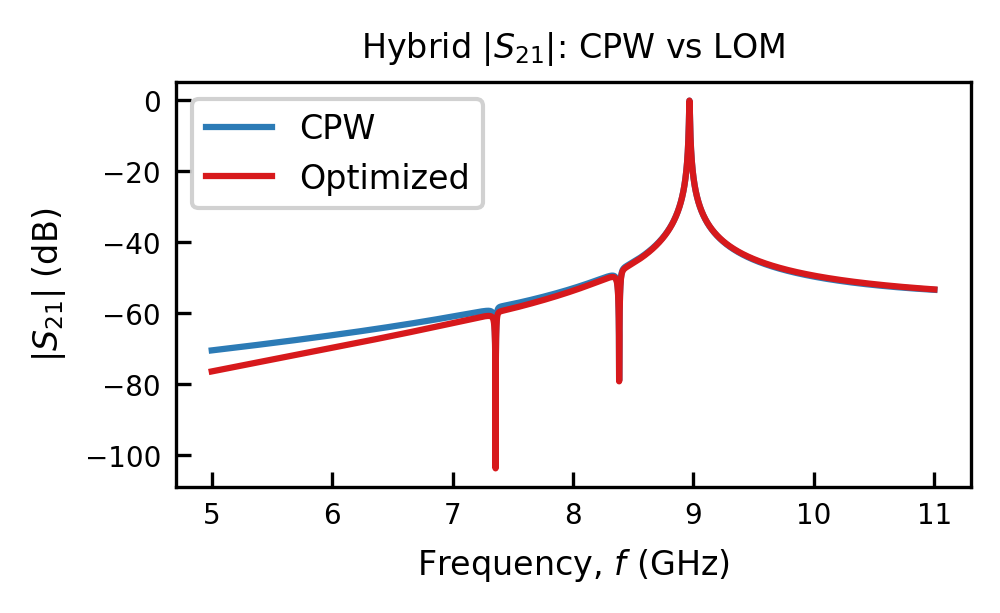

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: title={'center': 'Hybrid $|S_{21}|$: CPW vs LOM'}, xlabel='Frequency, $f$ (GHz)', ylabel='$|S_{21}|$ (dB)'>)

In [ ]:
seg_purcell_lc = [{"kind": "lc", "L": m_p.L, "C": m_p.C}]
seg_hangers_lc = [
    {"kind": "lc", "L": m.L, "C": m.C} for m in hanger_models
]

purcell_lc = sl.resonator_chain_network_2port(
    freq, seg_purcell_lc, Ccs_p, Ctogs=None, cpw_params=cpw, Z0=Z0,
)
hangers_lc = sl.hanger_resonator_network_2port(
    freq, seg_hangers_lc, Cc_taps, cpw_params=cpw, Z0=Z0,
)
hybrid_lc = purcell_lc ** hangers_lc


Plotting the transmission shows that there is strong agreement between the network of lumped elements and the fully distributed network:

In [ ]:
sl.plot_all_models(
    {"CPW": hybrid_cpw, "Optimized": hybrid_lc},
    m=1, n=0, quantity="db",
    title=r"Hybrid $|S_{21}|$: CPW vs LOM",
)


### 4b. Evaluate the accuracy

With the two networks, to go further than just a graph we can determine numerically how accurate their predicted peaks are.


In [7]:
notches_lc = sl.notches_below(hybrid_lc, thresh=0.7)
peaks_lc = np.sort(sl.resonances_from_s_max(hybrid_lc, m=1, n=0))

rows_n = []
for nc in notches_cpw:
    nl = min(notches_lc, key=lambda x: abs(x - nc))
    rows_n.append({
        "feature": "notch",
        "CPW_GHz": nc,
        "Lumped_GHz": nl,
        "error_MHz": (nl - nc) * 1e3,
        "error_%": 100.0 * (nl - nc) / nc,
    })

rows_p = []
for i, (pc, pl) in enumerate(zip(peaks_cpw[:3], peaks_lc[:3]), start=1):
    rows_p.append({
        "feature": f"peak {i}",
        "CPW_GHz": pc / 1e9,
        "Lumped_GHz": pl / 1e9,
        "error_MHz": (pl - pc) / 1e6,
        "error_%": 100.0 * (pl - pc) / pc,
    })

compare = pd.DataFrame(rows_n + rows_p)
print("Max |error_%|:", float(np.max(np.abs(compare["error_%"]))))
compare


Max |error_%|: 0.06169877287996161


,feature,CPW_GHz,Lumped_GHz,error_MHz,error_%
0,notch,7.3565,7.3565,0.0,0.000000
1,notch,8.3825,8.3825,0.0,0.000000
2,peak 1,7.2935,7.2980,4.5,0.061699
3,peak 2,8.3270,8.3285,1.5,0.018014
4,peak 3,8.9660,8.9660,0.0,0.000000


## 5. Lumped hybrid schematic

Same `hybrid_schematic_2port`, now with fitted LC tanks (no Ctog on the inline
block — OptimizedFit absorbs grounds).


In [8]:
sch_lc = sl.hybrid_schematic_2port(
    seg_purcell_lc, Ccs_p, seg_hangers_lc, Cc_taps,
    inline_Ctogs=None, cpw_params=cpw, freq=freq, Z0=Z0,
    annotations={"block": "hybrid LOM (OptimizedFit + HangerOptimizedFit)"},
)
sch_lc.save_svg(figdir / "hybrid_lc.svg")
sch_lc.save_html(figdir / "hybrid_lc.html")
print("saved figures/hybrid_lc.svg|.html")
sch_lc


saved figures/hybrid_lc.svg|.html


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.schematics.builders.hybrid_schematic_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'res1', 'label': 'resonator 1'}, {'id': 'hang1', 'label': 'hanger 1'}, {'id': 'hang2', 'label': 'hanger 2'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50.0}), Component(id='Cc1', type='cap', label='C_{c1}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='LC1', type='lc', label='LC 1', value='L = 523.12 pH\nC = 586.29 fF', ports=['a', 'gnd'], group='res1', orient='shunt', props={'L': 5.231200087252072e-10, 'C': 5.862871450849986e-13}), Component(id='Cc2', type='cap', label='C_{c2}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='H1', type='branch', label='', value='', ports=['a', 'gnd'], group='hang1', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c1}', 'value': '30.00 fF'}, {'type': 'lc', 'label': 'LC 1', 'value': 'L = 552.54 pH\nC = 622.36 fF'}]}), Component(id='H2', type='branch', label='', value='', ports=['a', 'gnd'], group='hang2', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c2}', 'value': '30.00 fF'}, {'type': 'lc', 'label': 'LC 2', 'value': 'L = 632.06 pH\nC = 710.54 fF'}]}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50.0})], nets=[Net(id='n1', ports=['P1.out', 'Cc1.a']), Net(id='n2', ports=['Cc1.b', 'LC1.a']), Net(id='n3', ports=['LC1.gnd', 'GND']), Net(id='n4', ports=['Cc1.b', 'Cc2.a']), Net(id='n5', ports=['Cc2.b', 'H1.a']), Net(id='n6', ports=['H1.gnd', 'GND']), Net(id='n7', ports=['Cc2.b', 'H2.a']), Net(id='n8', ports=['H2.gnd', 'GND']), Net(id='n9', ports=['Cc2.b', 'P2.in'])], annotations={'block': 'hybrid LOM (OptimizedFit + HangerOptimizedFit)'})